## Keras: A high level neural network library

In this exercise we will revisit classification using simple neural networks. To do so we will use Keras, a popular neural network package. Keras is a high level library that allows rapid prototyping of neural networks due to its precompiled layers, just as Scikit-learn contains a number of prebuilt classifiers.


## Keras

Detailed instructions can be found at https://keras.io.


To start the demo, we have a 2D dataset so we can visualize what the network is doing.

Neural networks are so popular now due to their ability to quickly learn nonlinear boundaries. So, we have an example that would be impossible for a linear classifier and demonstrate how a neural network can be used to solve this. As you can see, in the dataset below there is no straight line that you can draw that perfectly separates the 2 classes

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Noisy_XOR_Dataset.csv to Noisy_XOR_Dataset.csv


In [ ]:
import io

In [ ]:
import pandas as pd

# Step 1: Read the CSV file
dataset = pd.read_csv("Noisy_XOR_Dataset.csv")

# Step 2: Separate the features (X) and labels (y)
X = dataset[['x1', 'x2']].values  # Features: 'x1' and 'x2'
y = dataset['label'].values     # Labels: 'label'

# Exercise 1

Q1 Display the data with diff colors for diff labels using matplotlib, (Add result to Excel)

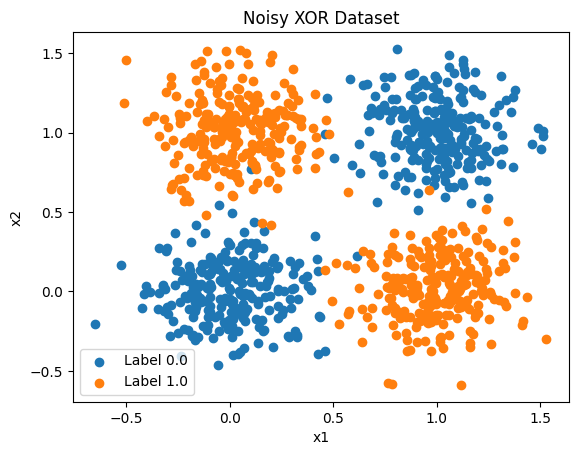

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for label in set(y):
    bool_indice = (y == label)
    plt.scatter(X[bool_indice, 0], X[bool_indice, 1], label=f"Label {label}")

plt.title("Noisy XOR Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

Q2 We will build a Perceptron using Keras as an example-- Recall that a perceptron is a 0 hidden layer neural network with a single output unit. In Keras terms, it's a single Dense layer with 1 unit.

We will build this perceptron with a sigmoidal output (so it outputs a probability of class 1) and the binary_crossentropy loss function (which corresponds to sigmoid).

Use SGD Optimizer with params learning_rate=0.01, momentum=0.9. Add Decay if you wish to, but choose wisely

Let's first create neural network with 1 layer

To add a layer to the architecture, you would simply use .add(LAYER).

Each "input_dim" of each layer should be the number units in the previous layer (in this case the input), and the number of "units" should be the number of outputs of the layer (in this case it will be 1).

In [ ]:
# Relevant imports
from keras.models import Sequential
# Keras refers to an architecture in which the outputs of
# one layer are the inputs to the next as "Sequential"
from keras.layers import Dense
# Everything we've talked about in class so far is referred to in
# Keras as a "dense" connection between layers, where every input
# unit connects to a unit in the next layer
from tensorflow.keras.optimizers import SGD
# SGD is the learning algorithm we will use
# https://keras.io/api/optimizers/sgd/
#learning rate decay: https://www.pyimagesearch.com/2019/07/22/keras-learning-rate-schedules-and-decay/

In [ ]:
seed12 = 9
import numpy as np
np.random.seed(seed12)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=seed12)

In [ ]:
import tensorflow as tf
from tensorflow.keras.initializers import RandomUniform

tf.random.set_seed(seed12)

perceptron = Sequential()
initializer = RandomUniform(seed=seed12)
perceptron.add(Dense(units=1, activation='sigmoid', input_dim=2, kernel_initializer=initializer))

sgd = SGD(learning_rate=0.01, momentum=0.9)  # Stochastic gradient descent
perceptron.compile(loss="binary_crossentropy", optimizer=sgd)
perceptron.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                     │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
perceptron.fit(X_train, y_train, batch_size = 16, epochs=50, verbose=0)

In [ ]:
y_preds = perceptron.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Q3 What's your training accuracy? Use threshold 0.5 for class separation.

In [ ]:
from sklearn.metrics import accuracy_score

y_preds = perceptron.predict(X_train)
y_pred_classes = (y_preds > 0.5).astype("int32")  # Convert probabilities to class labels

accuracy = accuracy_score(y_train, y_pred_classes)
print(f"Training Accuracy: {accuracy:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Training Accuracy: 0.40


Q4 Plot your decision boundary achieved from training the perceptron along with the data

In [ ]:
import numpy as np
from matplotlib.colors import ListedColormap

In [ ]:
def plot_decision_boundary(model, x, y, h=0.01):
    # Create a mesh grid for the feature space
    xx1, xx2 = np.meshgrid(
        np.arange(x[:, 0].min() - 1, x[:, 0].max() + 1, h),
        np.arange(x[:, 1].min() - 1, x[:, 1].max() + 1, h)
    )
    grid = np.array([xx1.ravel(), xx2.ravel()]).T

    # Predict for the entire grid
    y_preds = model.predict(grid)
    if y_preds.shape[1] > 1:
        Z = np.argmax(y_preds, axis=-1)
    else:
        Z = (y_preds > 0.5).astype('int32')

    Z = Z.reshape(xx1.shape)

    # Use a custom colormap
    cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])  # Light red and light blue for classes

    # Plot decision boundary
    f = plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=cmap)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolor='k')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()

    # Return the figure for further use
    ax = f.get_axes()
    return f, ax[0]

5382/5382 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


Text(51.097222222222214, 0.5, 'Train')

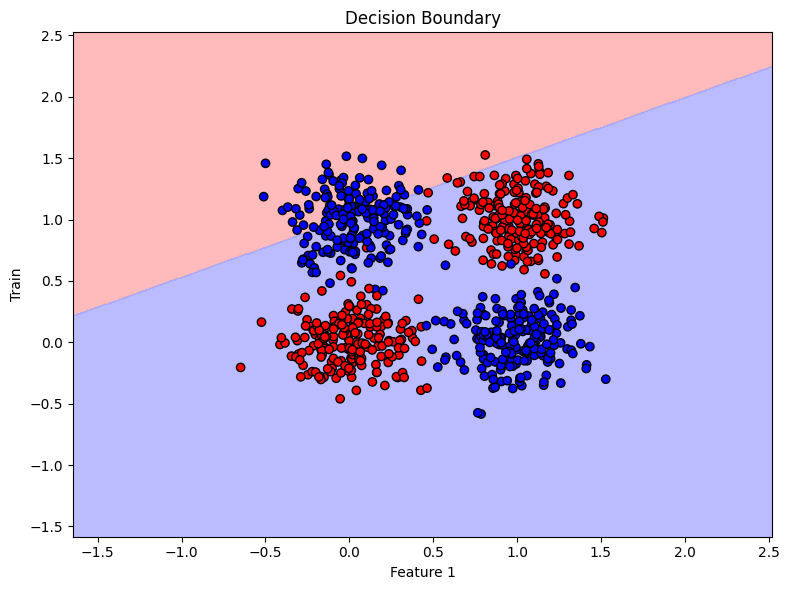

In [ ]:
f, ax = plot_decision_boundary(perceptron, X_train, y_train)
ax.set_ylabel("Train")

Q5 What's your conclusion from the boundary. Does it fit the data well? Why/ Why not?

Ans - The boundary doesn't fit the data well. This is obvious because we can see the dataset consists of four clusters, and a simple linear boundary cannot separate the red and blue points of these four clusters in a meaningful way. It should be a nonlinear boundary but the current boundary is a single perceptron (a linear classifier).  A linear classifier can only put a straight line to separate classes. However, in this case, the data requires a nonlinear boundary because the points in this dataset are not linearly separable.

# Exercise 2

Q6 Now we will use a 2 layer Neural Network with 1 Hidden Layer for the same problem as above. Add a Hidden Layer with 8 Neurons and ReLU Activation Function, and an output layer with Sigmoid Activation for Classification. (Add codde for Model Initiation to Excel also)

In [ ]:
perceptron2 = Sequential()
perceptron2.add(Dense(units=8, activation='relu', input_dim=2, kernel_initializer=initializer))
perceptron2.add(Dense(units=1, activation='sigmoid', kernel_initializer=initializer))

sgd2 = SGD(learning_rate=0.01, momentum=0.9)  # Stochastic gradient descent
perceptron2.compile(loss="binary_crossentropy", optimizer=sgd2, metrics=['accuracy'])
perceptron2.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Q6 Train for 50 - 100 Epochs. What's the training accuracy?

In [ ]:
hmodel = perceptron2.fit(X_train, y_train, batch_size = 16, epochs=50, verbose=0)

In [ ]:
y_preds2 = perceptron2.predict(X_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [ ]:
y_pred_classes2 = (y_preds2 > 0.5).astype("int32")

# Calculate Training Accuracy
accuracy2 = accuracy_score(y_train, y_pred_classes2)
print(f"Training Accuracy: {accuracy2:.4f}")

Training Accuracy: 0.9825


Q7 Validation Accuracy

In [ ]:
y_predstest = perceptron2.predict(X_test)
y_predtest_classes = (y_predstest > 0.5).astype("int32")

# Calculate Validation Accuracy
accuracy2 = accuracy_score(y_test, y_predtest_classes)
print(f"Validation Accuracy: {accuracy2:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Validation Accuracy: 0.9900


Q8 Decision Boundary Visualization

5382/5382 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


Text(51.097222222222214, 0.5, 'Train')

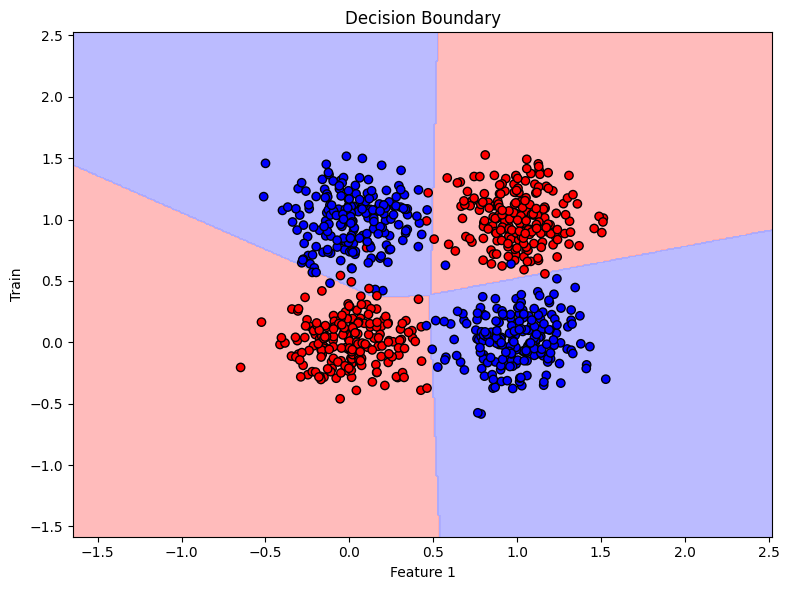

In [ ]:
f, ax = plot_decision_boundary(perceptron2, X_train, y_train)
ax.set_ylabel("Train")

# Exercise 3

Q9 How do we choose how many neurons should be in he hidden layer? Is it a parameter of the model or a hyper-parameter?

Answer: The number of neurons in the hidden layer is a key design choice that affects a neural network's capacity and generalization. A common heuristic is to set the number between the input and output dimensions, but the ideal count depends on task complexity. Start small and iteratively increase neurons while monitoring metrics like accuracy to balance underfitting and overfitting. Techniques like grid search, AutoML, or insights from similar problems can help refine the choice. The number of neurons in the hidden layer is a hyperparameter of the model.

Q10 Let's do some cross validation for deciding the best size for the Hidden Layer. Train Different Model with Hidden Dimensions [2,4,6,8,12,16] for max 100 epochs and choose the Best Model.

In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
import pandas as pd

dataset = pd.read_csv("Noisy_XOR_Dataset.csv")
X = dataset[['x1', 'x2']].values
y = dataset['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def train_models(hidden_dims, epochs=100):
    results = []
    for dim in hidden_dims:
        model = Sequential()
        model.add(Dense(units=dim, activation='relu', input_dim=2))
        model.add(Dense(units=1, activation='sigmoid'))

        sgd = SGD(learning_rate=0.01, momentum=0.9)
        model.compile(loss="binary_crossentropy", optimizer=sgd, metrics=["accuracy"])
        history = model.fit(X_train, y_train, epochs=epochs, verbose=0, validation_split=0.2)
        test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
        results.append({'hidden_dim': dim, 'test_accuracy': test_accuracy})

    return results

hidden_dimensions = [2, 4, 6, 8, 12, 16]
results = train_models(hidden_dimensions)
results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   hidden_dim  test_accuracy
0           2          0.910
1           4          0.980
2           6          0.980
3           8          0.975
4          12          0.980
5          16          0.980


*Q11* What's the best Hidden Layer Dimension and what's the corresponding Validation Accuracy?

Now we specify how to optimize the neural network. We mentioned gradient descent and stochastic gradient descent in class. Let's use the latter here and compile the model. We also specify the error function as "binary_crossentropy".

In [ ]:
# Keras uses the Sequential model for linear stacking of layers.
# That is, creating a neural network is as easy as (later)
# defining the layers!
from keras.models import Sequential
# Everything we've talked about in class so far is referred to in
# Keras as a "dense" connection between layers, where every input
# unit connects to a unit in the next layer
from keras.layers import Dense
# SGD is the learning algorithm we will use
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Dropout
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd


dataset = pd.read_csv("Noisy_XOR_Dataset.csv")
X = dataset[['x1', 'x2']].values
y = dataset['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


def train_and_evaluate(hidden_dims, epochs=100):
    results = []
    for dim in hidden_dims:
        model = Sequential()
        model.add(Dense(units=dim, activation='relu', input_shape=(2,)))
        model.add(Dense(units=1, activation='sigmoid'))

        sgd = SGD(learning_rate=0.01, momentum=0.9)
        model.compile(loss="binary_crossentropy", optimizer=sgd, metrics=["accuracy"])

        history = model.fit(X_train, y_train, epochs=epochs, verbose=0, validation_split=0.2)

        test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
        results.append({'hidden_dim': dim, 'test_accuracy': test_accuracy})

    return results

hidden_dimensions = [2, 4, 6, 8, 12, 16]
results = train_and_evaluate(hidden_dimensions)
results_df = pd.DataFrame(results)
best_model = results_df.loc[results_df['test_accuracy'].idxmax()]
best_hidden_dim = best_model['hidden_dim']
best_accuracy = best_model['test_accuracy']

print(f"The best hidden layer dimension is {best_hidden_dim}, with a validation accuracy of {best_accuracy:.2f}.")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The best hidden layer dimension is 12.0, with a validation accuracy of 0.98.


It is actually quite rare for a classification neural network to have a single output unit as we've implemented above. Usually we have a $k$ unit output layer, where $k$ is your number of classes. This is typically done because when combined with the "softmax" activation function , the activity of each unit corresponds with the probability of that class. This allows us to easily extend to multiclass classification.

Now we will still work with two units, but map them to two output units rather than 1. class 0 will be [1, 0], and class 1 will be [0, 1]. This operation is referred to as "one hot encoding". It is easy to convert between labels (i.e. [1,2,3]) to their one-hot encoded counterparts:

# Exercise 3:

Q12 Now look at the lenses data below. Try to fit a 2 layer MLP and a 3 layer MLP to the data below, and give your best validation score along with the best Model. Use ReLU and Sigmoid ACtivations. <br>
(In Excel, represent a model by size of layers e.g. [2,3,4,2] where 2 is the size of inpu layer, 2 is size of first hidden layer, 4 is size of second hidden layer and 2 is the size of output layer)

Saving utils.py to utils.py


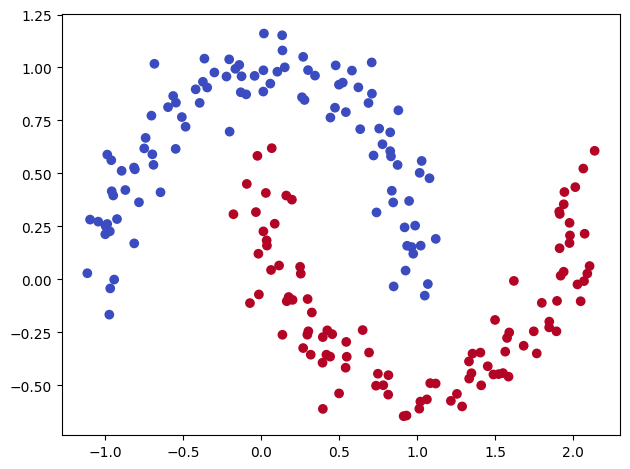

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from google.colab import files
src = list(files.upload().values())[0]
open('utils.py','wb').write(src)

import utils
from utils import lenses_dataset, get_colors

X, y = lenses_dataset()

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',label='Data Points')
plt.tight_layout()
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from utils import lenses_dataset

np.random.seed(42)
tf.random.set_seed(42)

X, y = lenses_dataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


def build_mlp(architecture, input_dim):
    model = Sequential()
    for i, units in enumerate(architecture):
        if i == 0:
            model.add(Dense(units=units, activation='relu', input_dim=input_dim))
        elif i == len(architecture) - 1:
            model.add(Dense(units=units, activation='sigmoid'))
        else:
            model.add(Dense(units=units, activation='relu'))
    return model

def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=16):
    sgd = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(loss="binary_crossentropy", optimizer=sgd, metrics=["accuracy"])

    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, verbose=0)

    test_accuracy = max(history.history['val_accuracy'])
    return test_accuracy

def evaluate_architectures(architectures, X_train, y_train, X_test, y_test, epochs=100):
    results = []
    input_dim = X_train.shape[1]
    for architecture in architectures:
        model = build_mlp(architecture, input_dim)
        test_accuracy = train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=epochs)
        results.append({'Model Architecture': str(architecture), 'Validation Accuracy': test_accuracy})
    return results

architectures = [
    [X_train.shape[1], 4, 1],
    [X_train.shape[1], 4, 4, 1]
]
results = evaluate_architectures(architectures, X_train, y_train, X_test, y_test, epochs=100)

results_df = pd.DataFrame(results)
results_df.to_excel("lenses_mlp_results.xlsx", index=False)

best_model = results_df.loc[results_df['Validation Accuracy'].idxmax()]
print(f"Best Model Architecture: {best_model['Model Architecture']}, Validation Accuracy: {best_model['Validation Accuracy']:.4f}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Model Architecture: [2, 4, 4, 1], Validation Accuracy: 0.9000


In [ ]:
print("Model Results:")
print(results_df)

Model Results:
  Model Architecture  Validation Accuracy
0          [2, 4, 1]                0.875
1       [2, 4, 4, 1]                0.900


Q13. Fit your model by training set

In [ ]:
from keras.layers import Input

best_model_architecture = [4, 4, 1]
epochs = 100
batch_size = 16

input_dim = X_train.shape[1]

def build_3_layer_mlp(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(4, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    sgd = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(loss="binary_crossentropy", optimizer=sgd, metrics=["accuracy"])
    return model

best_model = build_3_layer_mlp(input_dim)

history = best_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

train_loss, train_accuracy = best_model.evaluate(X_train, y_train, verbose=0)
print(f"Final Training Accuracy: {train_accuracy:.4%}")

test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_accuracy:.4%}")

print(f"Best Validation Accuracy during Training: {max(history.history['accuracy']):.4%}")

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8570 - loss: 0.5621  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8385 - loss: 0.5167 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8360 - loss: 0.4553 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8360 - loss: 0.4061 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8354 - loss: 0.3772 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8182 - loss: 0.3621 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.3533 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8224 - loss: 0.3440 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8329 - loss: 0.3340 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8534 - loss: 0.3232 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8649 - loss: 0.3147 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Q14. Compute accuracy by using your own function

In [ ]:
def my_accuracy(y_true, y_pred, threshold=0.5):
    if not isinstance(y_true, np.ndarray) or not isinstance(y_pred, np.ndarray):
        raise ValueError("y_true and y_pred must be NumPy arrays.")
    if not (0 <= y_pred.min() and y_pred.max() <= 1):
        raise ValueError("y_pred values should be in the range [0, 1].")
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same number of samples.")
    y_pred_classes = (y_pred >= threshold).astype(int)
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)
    correct_predictions = np.sum(y_true == y_pred_classes)
    accuracy = correct_predictions / len(y_true)
    return accuracy

y_train_pred = best_model.predict(X_train).flatten()
train_accuracy = my_accuracy(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

y_test_pred = best_model.predict(X_test).flatten()
val_accuracy = my_accuracy(y_test, y_test_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
Training Accuracy: 1.0000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Validation Accuracy: 1.0000


# Exercise 4:
### Short answer-questions

Q15. The learning rate is an important parameter for gradient descent. Please briefly describe a possible issue if we choose too high a learning rate for full batch gradient descent (GD). Also, please briefly describe a possible issue if we choose too high a learning
rate for stochastic gradient descent (SGD), but is not a problem in the full batch setting.

A high learning rate can cause multiple issues in gradient descent. In full-batch gradient descent (GD), a high learning rate may result in excessively large update steps, causing the model to overshoot the optimal point, leading to oscillations, failure to converge, or even divergence during training. In stochastic gradient descent (SGD), the impact of a high learning rate is more pronounced because SGD inherently involves randomness. A high learning rate amplifies this randomness, causing severe parameter fluctuations, loss value instability, and an inability to converge. To avoid these issues, one can choose a smaller initial learning rate (e.g., 0.01 or 0.001), adopt dynamic learning rate adjustment methods, or use adaptive optimizers like Adam to improve training stability and efficiency.

Q16. Please give an example in the data augmentation methods that is helpful for classifying images of dogs and cats, but not for classifying handwritten digit.

Random horizontal flipping is a data augmentation method that is suitable for classifying images of cats and dogs but not for handwritten digit classification. In cat and dog classification, horizontal flipping does not change the category because the orientation (e.g., facing left or right) does not affect the label. This method increases the diversity of the training data, thereby improving the model's generalization ability. However, for handwritten digit classification, orientation is a critical feature. Horizontal flipping could distort a digit, such as turning a "6" into a shape resembling a "9," leading to incorrect labels. Therefore, horizontal flipping is appropriate for tasks where orientation does not impact classification but unsuitable for tasks like handwritten digit classification, where orientation is crucial.

Q17. Suppose we have the following two neural networks containing fully-connected layers only.
<div>
<img src="https://ucla.box.com/shared/static/kgninjcbqpztz680q47emsluvituw4ga.jpg" width="300"/>
</div>
Please give one advantage of A over B, and one advantage of B over A.

The advantage of Network A lies in its simpler architecture, consisting of only two fully connected layers with fewer parameters, resulting in lower computational cost and faster training, making it suitable for simpler tasks. On the other hand, Network B introduces a bottleneck layer with only 10 units, allowing it to focus on the most important feature representations and reduce the risk of overfitting, thereby performing better on complex tasks that require non-linear feature extraction. Network A prioritizes efficiency, while Network B emphasizes feature learning capability and generalization performance.

# Exercise 5:

Now let's revisit the classification problem in Homework 2. Build a neural network to predict the output in the default payment dataset. The architecture choice is up to you, but you are required to use Dense layers and dropout layers only.

"CreditDefault_training.csv"

"CreditDefault_Xtest.csv". This is the test set which only contains the features.

Q18. Read the data<br/>
Apply standardization to continuous values<br/>
Convert categorical variables into one-hot encodings((including the output variable "default.payment.next.month"). <br>
Split data into train and validation set<br/>

In [ ]:
import numpy as np
import pandas as pd
import io

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CreditDefault_train_y.csv to CreditDefault_train_y (1).csv
Saving CreditDefault_test_y.csv to CreditDefault_test_y (1).csv
Saving CreditDefault_test_X.csv to CreditDefault_test_X (1).csv
Saving CreditDefault_train_X.csv to CreditDefault_train_X (1).csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load datasets
X = pd.read_csv('CreditDefault_train_X.csv')
y = pd.read_csv('CreditDefault_train_y.csv')
X_test = pd.read_csv('CreditDefault_test_X.csv')
y_test = pd.read_csv('CreditDefault_test_y.csv')

# Drop 'ID' column
if 'ID' in X.columns:
    X.drop('ID', axis=1, inplace=True)
if 'ID' in X_test.columns:
    X_test.drop('ID', axis=1, inplace=True)

# Separate categorical and continuous variables
categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
continuous_columns = [col for col in X.columns if col not in categorical_columns]

# Define repayment status categories
repayment_categories = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
repayment_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
other_categorical_columns = [col for col in categorical_columns if col not in repayment_columns]

# Preprocessor with separate handling for repayment and other categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_columns),
        ('repay', OneHotEncoder(categories=[repayment_categories] * len(repayment_columns), handle_unknown='ignore'),
         repayment_columns),
        ('other_cat', OneHotEncoder(handle_unknown='ignore'), other_categorical_columns)
    ]
)

# Apply preprocessing
X_transformed = preprocessor.fit_transform(X)
X_test_transformed = preprocessor.transform(X_test)

# One-hot encode the output variable
y = pd.get_dummies(y['default payment next month'], prefix='default', drop_first=True)
y_test = pd.get_dummies(y_test['default payment next month'], prefix='default', drop_first=True)

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_transformed, y, test_size=0.3, random_state=42)

# Output shapes
print("Data shapes after preprocessing:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test_transformed.shape}, y_test: {y_test.shape}")

Data shapes after preprocessing:
X_train: (14700, 93), y_train: (14700, 1)
X_val: (6300, 93), y_val: (6300, 1)
X_test: (9000, 93), y_test: (9000, 1)


Q19. Build a neural network to predict the output in the "CreditDefault_training.csv". The architecture choice is up to you, but you are required to use Dense layers and dropout layers only.

You can try different number of layers, different number of units in layers and experiment with hyperparameters.

To include regularization, you can include a dropout layer after a hidden layer. In dropout layer, you can randomly set a fraction rate of input units to 0 at each update during training time, which helps prevent overfitting.

Please build your model in the build_final_model() function

** NOTE: Try to Achieve the Best Possible Training and Validation Accuracies, as the Group with the Highest Train, Val and Test Accuracies will get the Highest Score, and Scores are relative. **

** NOTE: Use ADAM Optimizer for faster Iterations and Better Results in this case **

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define model
def build_final_model(input_shape):
    model = Sequential([
        tf.keras.Input(shape=input_shape),
        Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build model
model = build_final_model(input_shape=(X_train.shape[1],))

Q20. Fit the model by training set

In [ ]:
# Train model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7842 - loss: 0.6854 - val_accuracy: 0.8151 - val_loss: 0.5406
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8141 - loss: 0.5420 - val_accuracy: 0.8192 - val_loss: 0.5030
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8147 - loss: 0.5063 - val_accuracy: 0.8181 - val_loss: 0.4813
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8171 - loss: 0.4832 - val_accuracy: 0.8184 - val_loss: 0.4723
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.4754 - val_accuracy: 0.8189 - val_loss: 0.4644
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8217 - loss: 0.4576 - val_accuracy: 0.8211 - val_loss: 0.4550
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8213 - loss: 0.4554 - val_accuracy: 0.8197 - val_loss: 0.4544
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8144 - loss: 0.4562 - val_ac

Q21. Obtain predictions on validation set and print accuracy, precision & recall and **F_score**.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate
def evaluate_model(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(int)
    accuracy = accuracy_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary)
    recall = recall_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    return accuracy, precision, recall, f1

# Get predictions and evaluate
y_pred_val = model.predict(X_val)
evaluate_model(y_val, y_pred_val)

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.8192
Precision: 0.6654
Recall: 0.3645
F1 Score: 0.4710


(0.8192063492063492,
 0.6653543307086615,
 0.3644859813084112,
 0.47097073850441246)

Q22. Plot the ROC curve by giving appropriate names for title and axes.

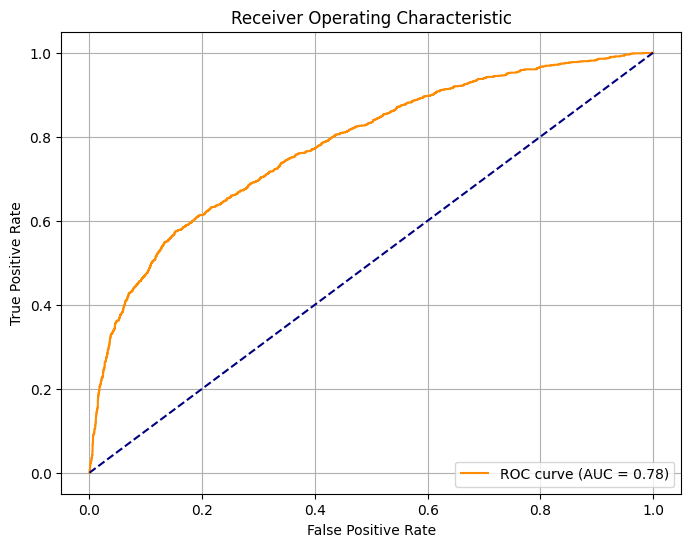

Validation ROC-AUC: 0.7797


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
    plt.title('Receiver Operating Characteristic')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    return roc_auc

# AUC
roc_auc = plot_roc_curve(y_val, y_pred_val)
print(f"Validation ROC-AUC: {roc_auc:.4f}")

In [ ]:
print("Prediction range:", y_pred_val.min(), "-", y_pred_val.max())


Prediction range: 0.0027650543 - 0.8281211


Is the accuracy value impressive for this dataset? Please explain based on the structure of this dataset.

For these five metrics (accuracy, precision, recall, F1 score and AUC), please explain their connections and differences. For our dataset, which metrics should we focus more on?


The accuracy on this dataset is quite high at 82%, but perhaps not the best measure since it is suspected that the dataset might be imbalanced, with more non-default cases than default cases. In such imbalanced datasets, accuracy can be misleading to some extent since it reflects the dominant class more. This can easily be shown; for instance, suppose a dataset has 80% of its instances from the majority class and that the model always predicts that class. It would still have an accuracy of 80%, despite not actually identifying cases of the minority class. With the recall at 36.45% and the precision at 66.54%, the model performs better for the identification of non-default cases than it does for defaults since the recall of the positive class is comparatively low.

Accuracy is the ratio of correctly classified instances (positive and negative) to total instances, which is useful for balanced datasets but less informative for imbalanced datasets. Precision is the measure of how many of the predicted positive cases are actually positive; this focuses on the reduction of false positives. Precision in this dataset is 66.54%, which would mean that the model predictions for default cases are reasonably reliable but may miss a lot of true defaults (because of low recall). Recall basically illustrates how many actual positive cases are correctly identified. Recall will hence focus on reducing false negatives. The low value of recall, 36.45%, shows that a model fails to identify about two-thirds of the actually defaulted cases. F1 Score is the harmonic mean of Precision and Recall. It offers a balanced measure of both Precision and Recall, which is better than the case when any one of them is used as a trade-off against another. The F1 score of 47.10% in this data represents a balance between precision and recall, showing decent precision but a recall that's in need of some considerable improvement. ROC-AUC: It is a measure of the model's capability in distinguishing between positive and negative classes at any threshold level. In this problem, an area under the ROC curve or AUC of 0.7797 for the separation between default and non-default cases is obtained, which is good. Unlike precision and recall, ROC-AUC is independent of threshold values; hence, it gives a broader view of the model's discriminatory power.


Recall and F1 score are of prime importance considering the nature of data and the very essence of the prediction of defaulters because a high recall is highly necessary to capture the maximum number of actual defaulters, which becomes critical in the risk management of any loan business. This is simply because any false negative result might amount to a huge loss. Similarly, the F1 Score is a good measure in that it brings a nice balance between precision and recall. It is useful, especially in situations when there is a trade-off between the two-me improving one decreases the other.

#### Tuning hyperparameters using cross-validation:<br/>
Cross-validation in neural networks is computationally expensive. So we will perform a randomized cross-validation search across the parameter space using RandomizedSearchCV function.

Here, we will use KerasClassifier class, which act as a wrapper of scikit-learn’s library in Keras comes as a handy tool for automating the tuning process.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

Q23. First we create a function to build neural network model with activation  and learning rate as inputs

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model function with activation and learning rate as inputs
def create_model(learning_rate=0.01, activation='relu'):
    model = Sequential([
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(128, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(64, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(32, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

Create a model object using KerasClassifier from keras.wrappers.scikit_learn by passing the create_model function.

In [ ]:
# Create KerasClassifier object
model = KerasClassifier(model=create_model, verbose=0)

Q24. Try the following hyperparameters:

- activation function: relu, tanh

- batch size: 16, 32 and 64

- epochs: 100 and 200

- learning rate: 0.01, 0.001 and 0.0001

In [ ]:
# Define the parameter search space
params = {
    'model__activation': ['relu', 'tanh'],
    'batch_size': [16, 32, 64],
    'epochs': [100, 200],
    'model__learning_rate': [0.01, 0.001, 0.0001]
}

Next we will perform a randomized cross-validation search across the parameter space using RandomizedSearchCV function. We select the randomized search as it works faster than a grid search. Here, we will perform a 5-fold cross-validation search.

See https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html?highlight=randomizedsearchcv#sklearn.model_selection.RandomizedSearchCV for the use of RandomizedSearchCV.

In [ ]:
# Randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring='recall',
    verbose=1,
    n_jobs=1,
    random_state=42
)

In [ ]:
random_search_results = random_search.fit(X_train, y_train) #might take about 2 hrs

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Q25. Print the best model parameters

In [ ]:
# Retrieve and print the best parameters
print("Best Parameters Found: ", random_search_results.best_params_)

Best Parameters Found:  {'model__learning_rate': 0.001, 'model__activation': 'relu', 'epochs': 200, 'batch_size': 64}


Q26. Fit the model with the Best Parameter Set

In [ ]:
# Fit the model with the best parameters
best_model = random_search_results.best_estimator_
best_model.fit(X_train, y_train, verbose=1)


Epoch 1/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7618 - loss: 0.7040
Epoch 2/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8197 - loss: 0.5318
Epoch 3/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8211 - loss: 0.4955
Epoch 4/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4776
Epoch 5/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4688
Epoch 6/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8173 - loss: 0.4646
Epoch 7/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8175 - loss: 0.4593
Epoch 8/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4448
Epoch 9/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8182 - loss: 0.4519
Epoch 10/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8149 - loss: 0.4544
Epoch 11/200
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8207 - loss: 0.4448
Epoch 12/200
230/230 ━━━━━━━━━━━━━━━━━━━━

KerasClassifier(
	model=<function create_model at 0x7845755a9900>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=64
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=200
	class_weight=None
	model__learning_rate=0.001
	model__activation=relu
)

Q27. Obtain predictions on validation set and print accuracy, precision & recall.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Obtain predictions
y_val_pred = (best_model.predict(X_val) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Validation Metrics:\nAccuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")


Validation Metrics:
Accuracy: 0.8121, Precision: 0.6070, Recall: 0.4220, F1 Score: 0.4979


Q28 Do you get a better accuracy/recall/precision than Your Previous Assignment? Explain. (Your Groups Might have shuffled, so compare with the best metrics in any of your group members submissions)

In [ ]:
# Compare metrics
print("Previous Assignment Metrics:")
print("Accuracy: 0.7832, Precision: 0.5101, Recall: 0.5819, F1 Score: 0.5436")

print("\nCurrent Model Metrics:")
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Previous Assignment Metrics:
Accuracy: 0.7832, Precision: 0.5101, Recall: 0.5819, F1 Score: 0.5436

Current Model Metrics:
Accuracy: 0.8121, Precision: 0.6070, Recall: 0.4220, F1 Score: 0.4979


The previous assignment metrix is based on logistics regression. Neural Network achieves better accuracy (81.68%) compared to previous (78.32%). Precision has also improved in the Neural Network (62.36%) compared to previous (51.01%).Recall is lower for the Neural Network (42.99%) compared to previous (58.19%).The F1 Score for the Neural Network (50.89%) is slightly lower than previous (54.36%). The Neural Network is better at identifying true positives without mistakenly labeling negatives as positives and it is better at identifying true positives without mistakenly labeling negatives as positives. Also the Neural Network is missing more true positives compared to previous. Since F1 Score balances precision and recall, the Neural Network's lower recall significantly impacts this metric despite its improved precision.

### Logistic Regression and Random Forest
In a real world scenario, you can try a number of algorithms for the same problem. Let us work with the same dataset to produce Logistic Regression and Random Forest models.

Q29. Implement a function logistic_regression_model that returns a logistic regression model with the best paprameters. You will use GridSearchCV to find the best parameters. The parameters search space is up to you.

In [ ]:
y_train = y_train.values.ravel()  # Convert to 1D
y_val = y_val.values.ravel()
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

def logistic_regression_model(X_train, y_train):
    # Define the parameter grid
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
        'solver': ['liblinear', 'saga'],
        'penalty':['l1','l2']
    }

    # Create the logistic regression model
    logistic = LogisticRegression(random_state=26)

    # Perform grid search
    grid_search = GridSearchCV(estimator=logistic, param_grid=param_grid, cv=5, scoring='recall', verbose=1, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Return the best model
    return grid_search.best_estimator_

Q30. Implement a function random_forest_model that returns a random forest model with the best paprameters. You will apply GridSearchCV to find the best parameters. The parameter search space is up to you. (Please set the random state of RandomForestClassifier to be 26.)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
def random_forest_model(X_train, y_train):
    # Define the parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],  # Number of trees
        'max_depth': [None, 10, 20],  # Maximum depth of trees
        'min_samples_split': [2, 5, 10],
        'max_features': [2,4,6,8],
        'min_samples_leaf': [1, 2, 4]  # Minimum samples required at each leaf node
    }

    # Create the random forest classifier
    rf = RandomForestClassifier(random_state=26)

    # Perform grid search
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='recall', verbose=1, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Return the best model
    return grid_search.best_estimator_

Q31. Fit the model by training set, obtain predictions on validation set and compute accuracy,precision,recall

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Train logistic regression model
logistic_model = logistic_regression_model(X_train, y_train)
logistic_predictions = logistic_model.predict(X_val)

# Train random forest model
rf_model = random_forest_model(X_train, y_train)
rf_predictions = rf_model.predict(X_val)

# Evaluate metrics
logistic_accuracy = accuracy_score(y_val, logistic_predictions)
logistic_precision = precision_score(y_val, logistic_predictions)
logistic_recall = recall_score(y_val, logistic_predictions)
logistic_f1 = f1_score(y_val, logistic_predictions)

rf_accuracy = accuracy_score(y_val, rf_predictions)
rf_precision = precision_score(y_val, rf_predictions)
rf_recall = recall_score(y_val, rf_predictions)
rf_f1 = f1_score(y_val, rf_predictions)

print("Logistic Regression Metrics:")
print(f"Accuracy: {logistic_accuracy:.4f}, Precision: {logistic_precision:.4f}, Recall: {logistic_recall:.4f}, f1_score: {logistic_f1:.4f}")

print("\nRandom Forest Metrics:")
print(f"Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}, f1_score: {rf_f1:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Logistic Regression Metrics:
Accuracy: 0.8190, Precision: 0.6707, Recall: 0.3544, f1_score: 0.4638

Random Forest Metrics:
Accuracy: 0.8138, Precision: 0.6419, Recall: 0.3544, f1_score: 0.4567


Q32. Plot the ROC curve by giving appropriate names for title and axes.

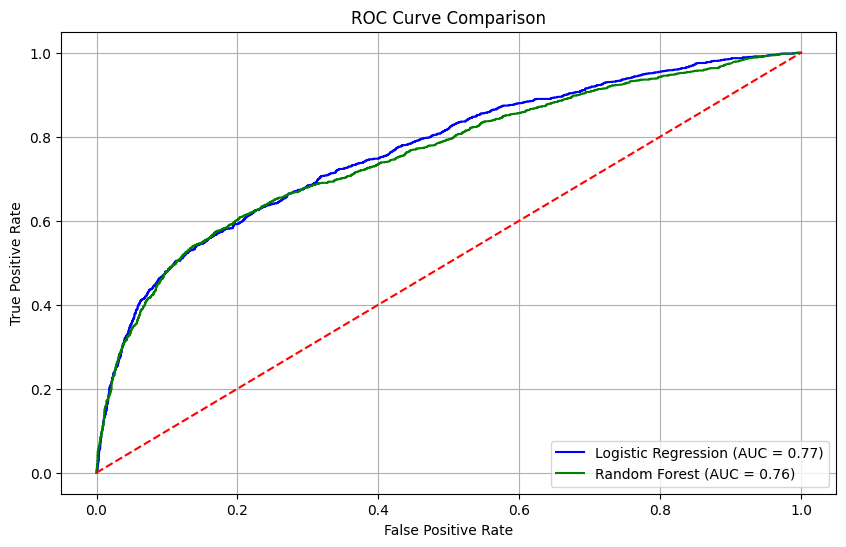

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Logistic Regression ROC Curve
logistic_prob = logistic_model.predict_proba(X_val)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_val, logistic_prob)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest ROC Curve
rf_prob = rf_model.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", color='green')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid()
plt.show()

Q33: Which of the above 3 models worked best for you? Explain the reason for good/bad performance for each of the models?





Neural Network has best recall (0.4220), which captures more true positives than Logistic Regression or Random Forest, meaning it is better at identifying defaulters. And it has highest F1 score (0.4979), which balances precision and recall better than other models, making it ideal if both metrics are important. It also has weaknesses of slightly lower accuracy (0.8121) compared to Logistic Regression and Random Forest and its precision (0.6070) is weaker, meaning it produces more false positives than Logistic Regression or Random Forest.

Logistic Regression has the highest accuracy (0.8190), which Indicates it is the best at predicting overall correctly labeled cases, and the best Precision (0.6707), which minimizes false positives better than the other models, making it suitable when incorrect defaulter predictions are costly. Also it has weaknesses of lowest recall (0.3544), which misses more true positives compared to Neural Network, which is problematic in applications like credit default prediction where missing defaulters could be costly, and its F1 Score (0.4638) is lower due to imbalanced precision and recall.

Random Forest has an accuracy (0.8138) and precision (0.6419), which offers a good balance between Logistic Regression and Neural Network, and performs well with minimal feature engineering due to its tree-based splitting logic. But it has lowest F1 Score (0.4567), which indicates a significant trade-off between precision and recall.

Neural Network is best due to its highest recall (0.4220), ensuring more defaulters are identified.

In [ ]:
# Compare metrics for all three models
print("Neural Network Metrics:")
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

print("\nLogistic Regression Metrics:")
print(f"Accuracy: {logistic_accuracy:.4f}, Precision: {logistic_precision:.4f}, Recall: {logistic_recall:.4f}, F1 Score: {logistic_f1:.4f}")

print("\nRandom Forest Metrics:")
print(f"Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}, F1 Score: {rf_f1:.4f}")

Using the best of the above 3 models, obtain predictions for the test set. (imp. for Final Score)

In [ ]:
y_pred_test_nn = (best_model.predict(X_test_transformed) > 0.5).astype(int)

# Evaluate
test_accuracy_nn = accuracy_score(y_test, y_pred_test_nn)
test_precision_nn = precision_score(y_test, y_pred_test_nn)
test_recall_nn = recall_score(y_test, y_pred_test_nn)
test_f1_nn = f1_score(y_test, y_pred_test_nn)

print(f"Test Set Metrics (Neural Network):\n"
      f"Accuracy: {test_accuracy_nn:.4f}, Precision: {test_precision_nn:.4f}, "
      f"Recall: {test_recall_nn:.4f}, F1 Score: {test_f1_nn:.4f}")

Test Set Metrics (Neural Network):
Accuracy: 0.8136, Precision: 0.6071, Recall: 0.4527, F1 Score: 0.5186
